In [1]:
##### Creates maps of capital and labor intensities (national & sub-national)

import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches

In [2]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# Import sub-national data

sub_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")

sub_geo_capital = gpd.read_file(f"{cd}/Data/Clean/Capital_stock/subnational_capital_stock_final_GEO.shp")
sub_geo_labor = gpd.read_file(f"{cd}/Data/Clean/Labor/subnational_labor_final_geo.shp")

# Import country data

country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_shp = gpd.read_file("/Users/carinamanitius/Documents/Data/Admin_Boundaries/gadm_410-levels.gpkg", layer='ADM_0')

country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures"

In [3]:
### Data prep

# align crs

crs = "ESRI:54042"

sub_geo_capital = sub_geo_capital.to_crs(crs)
sub_geo_labor = sub_geo_labor.to_crs(crs)
country_shp = country_shp.to_crs(crs)

# prep country shp 
country_shp = country_shp.merge(country_codes, left_on='GID_0', right_on='SHP_code', how='inner')

# join data to shape
sub_geo_capital = sub_geo_capital.merge(sub_capital, on='PROJ_ID', how='inner')
sub_geo_labor = sub_geo_labor.merge(sub_labor, on='PROJ_ID', how='inner')

country_shp = country_shp.merge(country_intensities, on='ISO3', how='outer')

In [4]:
##### Create groupings for data

# capital 
cap_bins = [0, 0.5, 1, 2, 5, float('inf')]
cap_labels = ['0-0.5', '0.5-1', '1-2', '2-5', '5+']

sub_geo_capital['intensity_bucket'] = pd.cut(
    sub_geo_capital['capital_intensity_USD_per_USD'],
    bins=cap_bins,
    labels=cap_labels
)

# labor 
lab_bins = [0, 10, 50, 500, 1000, float('inf')]
lab_labels = ['0-10', '10-50', '50-500', '500-1,000', '1,000+']

sub_geo_labor['intensity_bucket'] = pd.cut(
    sub_geo_labor['labor_intensity_jobs_per_million_USD'],
    bins=lab_bins,
    labels=lab_labels
)


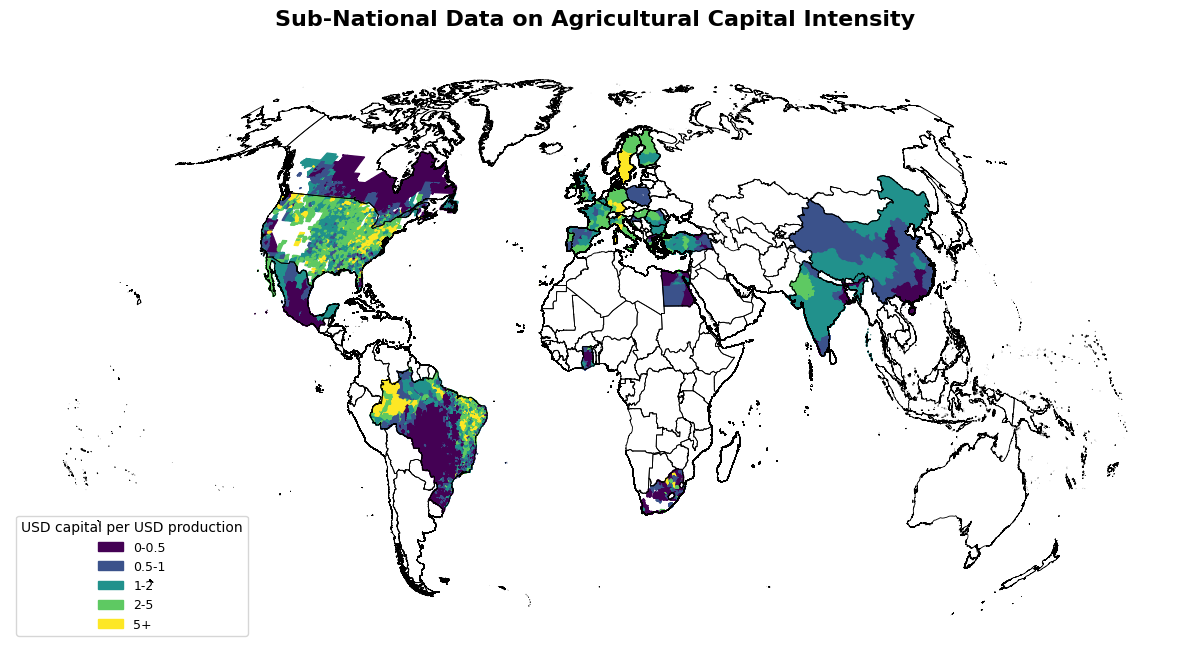

In [5]:
##### Plot sub-national capital intensity 

colors = plt.cm.viridis([i / (len(cap_labels) - 1) for i in range(len(cap_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
sub_geo_capital.plot(
    column='intensity_bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=cap_labels[i]) for i in range(len(cap_labels))]
ax.legend(
    handles=patches,
    title="USD capital per USD production",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Sub-National Data on Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_capital_intensity.png", dpi=300, bbox_inches='tight')

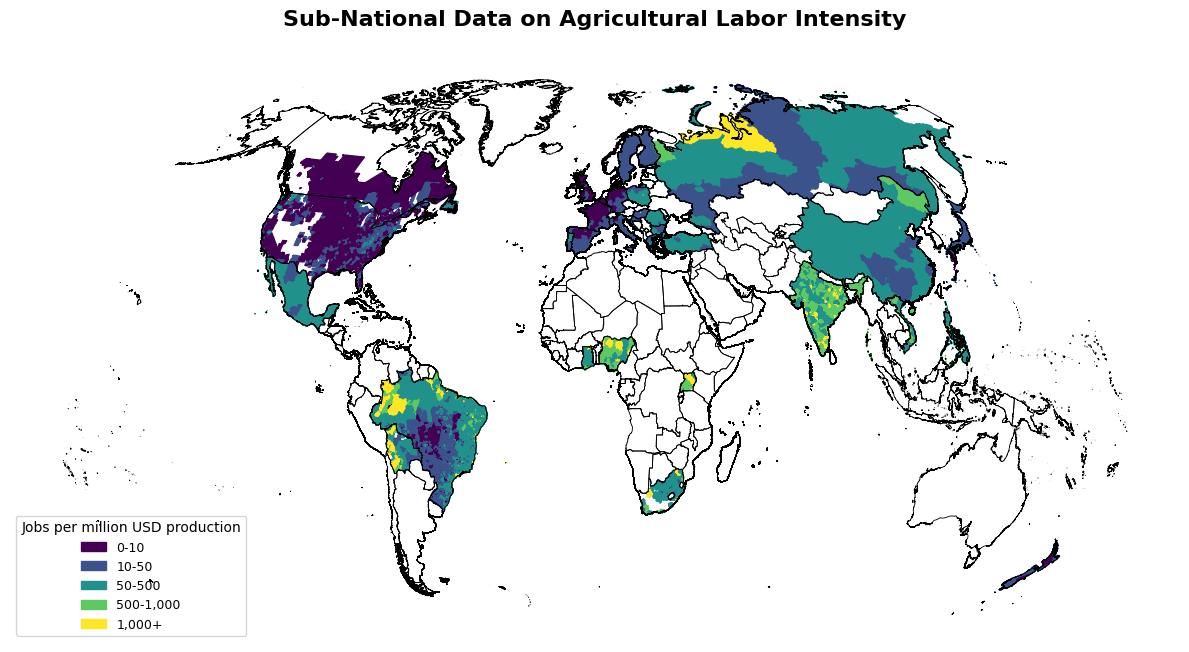

In [6]:
##### Plot sub-national labor intensity 

colors = plt.cm.viridis([i / (len(lab_labels) - 1) for i in range(len(lab_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
sub_geo_labor.plot(
    column='intensity_bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=lab_labels[i]) for i in range(len(lab_labels))]
ax.legend(
    handles=patches,
    title="Jobs per million USD production",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("Sub-National Data on Agricultural Labor Intensity", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/subnational_labor_intensity.png", dpi=300, bbox_inches='tight')

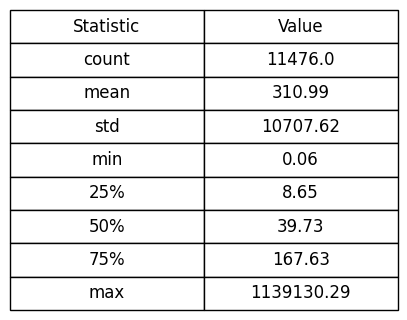

In [7]:
### Get basic stats 

stats = sub_geo_labor['labor_intensity_jobs_per_million_USD'].describe().round(2)  

stats_df = pd.DataFrame(stats).reset_index()
stats_df.columns = ['Statistic', 'Value']

### Create fig of table
fig, ax = plt.subplots(figsize=(5, 2))  

ax.axis('off')

# Create table
table = ax.table(
    cellText=stats_df.values,
    colLabels=stats_df.columns,
    cellLoc='center',
    loc='center'
)

# Styling 
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)  

plt.show()

In [8]:
##### Use same groupings for country data

# capital 
cap_bins = [0, 0.5, 1, 2, 5, float('inf')]
cap_labels = ['0-0.5', '0.5-1', '1-2', '2-5', '5+']

country_shp['cap_intensity_bucket'] = pd.cut(
    country_shp['capital_intensity_USD_per_USD'],
    bins=cap_bins,
    labels=cap_labels
)

# labor 
lab_bins = [0, 10, 50, 500, 1000, float('inf')]
lab_labels = ['0-10', '10-50', '50-500', '500-1,000', '1,000+']

country_shp['lab_intensity_bucket'] = pd.cut(
    country_shp['labor_intensity_jobs_per_million_USD'],
    bins=lab_bins,
    labels=lab_labels
)


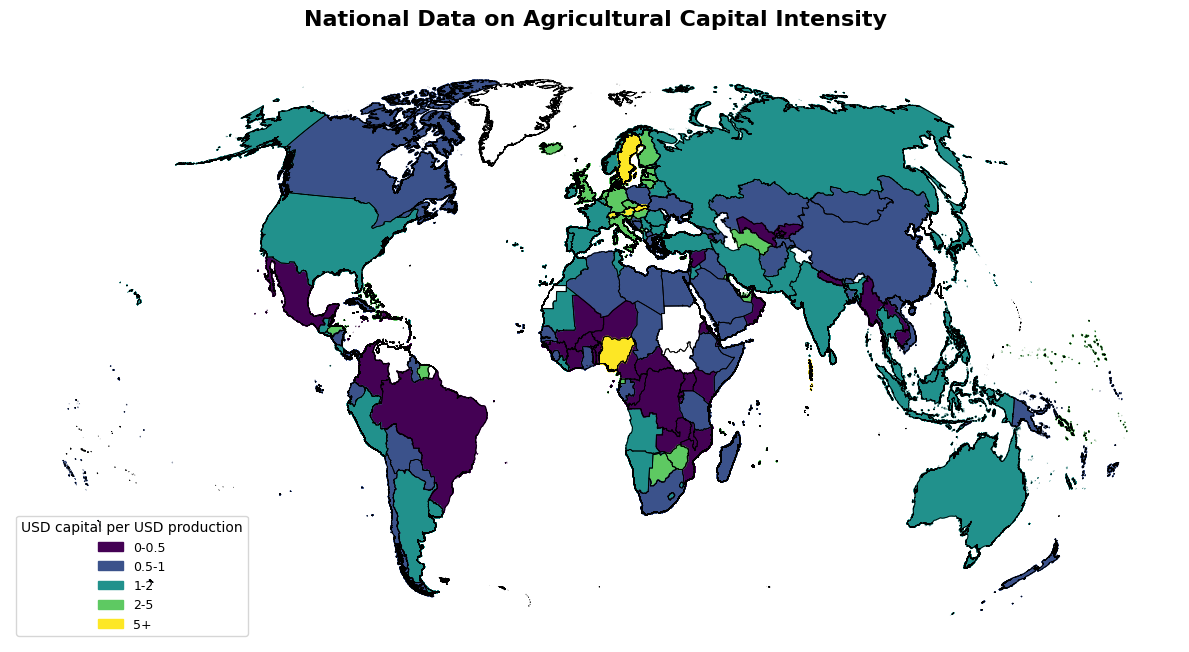

In [9]:
##### Plot national capital intensity 

colors = plt.cm.viridis([i / (len(cap_labels) - 1) for i in range(len(cap_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
country_shp.plot(
    column='cap_intensity_bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=cap_labels[i]) for i in range(len(cap_labels))]
ax.legend(
    handles=patches,
    title="USD capital per USD production",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("National Data on Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/national_capital_intensity.png", dpi=300, bbox_inches='tight')

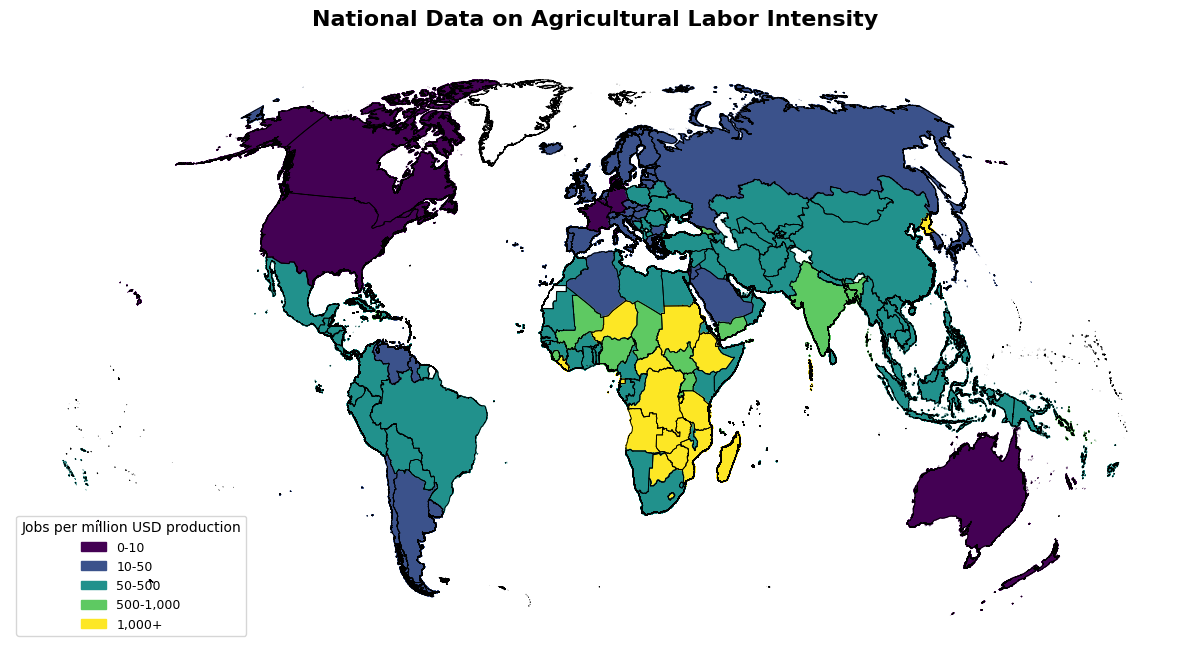

In [10]:
##### Plot national labor intensity 

colors = plt.cm.viridis([i / (len(lab_labels) - 1) for i in range(len(lab_labels))])

### Plot
fig, ax = plt.subplots(figsize=(12,8))

# Plot buckets
country_shp.plot(
    column='lab_intensity_bucket',
    cmap='viridis',
    edgecolor='face',
    ax=ax,
    legend=False,  # manual legend below
    zorder=2
)

# Add country boundaries
country_shp.boundary.plot(
    ax=ax,
    color='black',
    linewidth=0.6,
    zorder=10
)

# Manual discrete legend
patches = [mpatches.Patch(color=colors[i], label=lab_labels[i]) for i in range(len(lab_labels))]
ax.legend(
    handles=patches,
    title="Jobs per million USD production",
    loc='lower left',
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Aesthetics
ax.set_axis_off()  
ax.set_title("National Data on Agricultural Labor Intensity", fontsize=16, weight='bold', pad=20)
plt.tight_layout()

plt.show()

fig.savefig(f"{fd}/national_labor_intensity.png", dpi=300, bbox_inches='tight')